In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# OOD performance

In [16]:
df_base_path = '../results'

In [17]:
# Load your three dataframes
baseline_df = pd.read_csv(f"{df_base_path}/baseline_by_celltype_correlations.csv")
cellina_df = pd.read_csv(f"{df_base_path}/cellina_by_celltype_correlations.csv")
cpa_df = pd.read_csv(f"{df_base_path}/cpa_by_celltype_correlations.csv")

# remove epithelial row from cpa
cpa_df = cpa_df[cpa_df['celltype'] != 'Epithelial']

# Add a column to identify the source dataframe
baseline_df['method'] = 'baseline'
cpa_df['method'] = 'cpa'
cellina_df['method'] = 'cellina'

# Combine them
df_all = pd.concat([baseline_df, cpa_df, cellina_df], ignore_index=True)

# Melt the dataframe so we can plot pearson and spearman separately
df_melt = df_all.melt(id_vars=['celltype', 'method'], value_vars=['pearson', 'spearman'],
                      var_name='correlation', value_name='value')

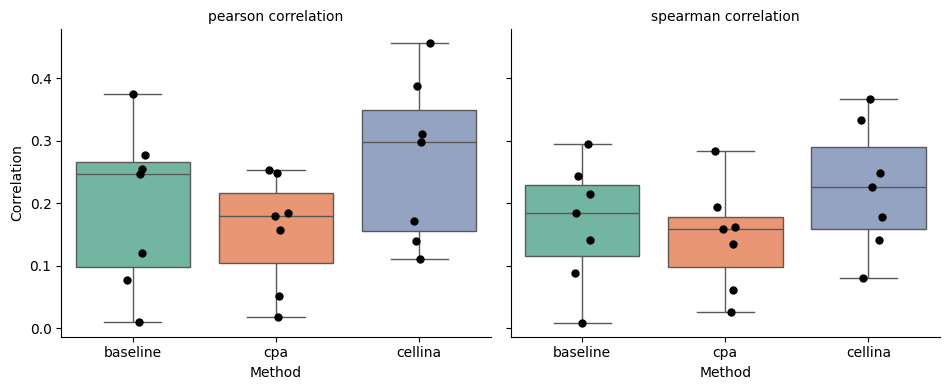

In [18]:
g = sns.catplot(
    data=df_melt, kind="box",
    x="method", y="value", hue="method",
    col="correlation",  # separate plots for pearson and spearman
    dodge=False, palette="Set2",
    height=4, aspect=1.2
)

# Add the individual points (dots) for each cell type
for ax, corr_type in zip(g.axes[0], ['pearson', 'spearman']):
    sns.stripplot(
        data=df_melt[df_melt['correlation']==corr_type],
        x='method', y='value', color='black', size=6, ax=ax, jitter=True
    )

g.set_axis_labels("Method", "Correlation")
g.set_titles("{col_name} correlation")
plt.show()

# LFC agreement between observed and reconstructed counts

In [19]:
cellina_de = pd.read_csv(f"{df_base_path}/cellina_de.csv", index_col=0).T
cpa_de = pd.read_csv(f"{df_base_path}/cpa_de.csv", index_col=0).T

In [20]:
cpa_de.index.name = "celltype"
cellina_de.index.name = "celltype"

/tmp/ipykernel_2026619/1853090153.py:14: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x="Correlation", y="Value", hue="method", data=df_melted,


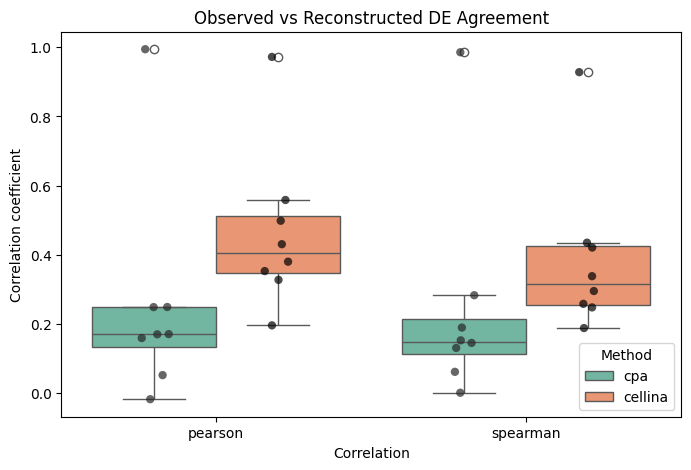

In [21]:
# Add a column to identify the source dataframe
cpa_de['method'] = 'cpa'
cellina_de['method'] = 'cellina'

# Combine both DataFrames
df_all = pd.concat([cpa_de, cellina_de])

# Melt for seaborn: long-form
df_melted = df_all.reset_index().melt(id_vars=["celltype", "method"], var_name="Correlation", value_name="Value")

# Plot
plt.figure(figsize=(8,5))
sns.boxplot(x="Correlation", y="Value", hue="method", data=df_melted, palette="Set2")
sns.stripplot(x="Correlation", y="Value", hue="method", data=df_melted,
              dodge=True, color="black", size=6, jitter=True, alpha=0.7)

# Remove duplicate legend entries from stripplot
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Method")

plt.title("Observed vs Reconstructed DE Agreement")
plt.ylabel("Correlation coefficient")
plt.show()

# E-distances between observed and reconstructed cells

In [22]:
cellina_edist = pd.read_csv(f"{df_base_path}/cellina_edist.csv", index_col=0)
cpa_edist = pd.read_csv(f"{df_base_path}/cpa_edist.csv", index_col=0)

In [23]:
cpa_edist.index.name = "celltype"
cellina_edist.index.name = "celltype"

/tmp/ipykernel_2026619/1993656564.py:14: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x="Edistance", y="Value", hue="method", data=df_melted,


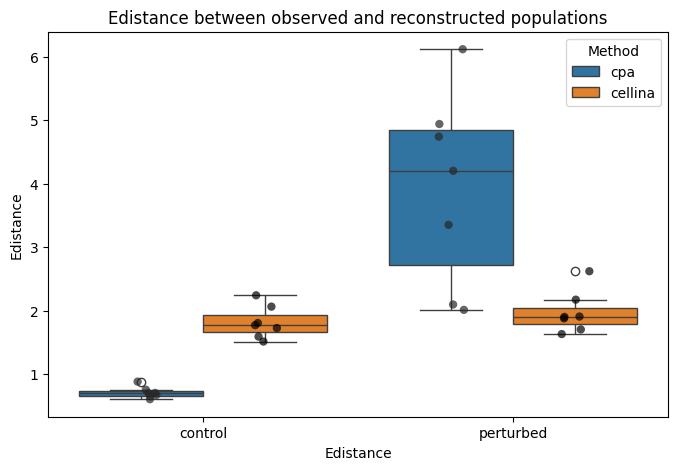

In [24]:
# Add a column to identify the source dataframe
cpa_edist['method'] = 'cpa'
cellina_edist['method'] = 'cellina'

# Combine both DataFrames
df_all = pd.concat([cpa_edist, cellina_edist])

# Melt for seaborn: long-form
df_melted = df_all.reset_index().melt(id_vars=["celltype", "method"], var_name="Edistance", value_name="Value")

# Plot
plt.figure(figsize=(8,5))
sns.boxplot(x="Edistance", y="Value", hue="method", data=df_melted, palette="tab10")
sns.stripplot(x="Edistance", y="Value", hue="method", data=df_melted,
              dodge=True, color="black", size=6, jitter=True, alpha=0.7)

# Remove duplicate legend entries from stripplot
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Method")

plt.title("Edistance between observed and reconstructed populations")
plt.ylabel("Edistance")
plt.show()